# Deep Space Navigation: Live Judge Demo

This notebook is designed for a smooth live presentation. It uses the saved trained-model artifacts in `outputs/patchtst_nasa_p1` instead of retraining during the demo, then runs the real-time S-1 mission-response prototype from `new_scripts/`.

What the audience will see:

1. The trained PatchTST model configuration and saved inference summary.
2. How anomaly scores are produced from forecast error.
3. Visual evidence of detections on NASA SMAP/MSL telemetry.
4. A live S-1 anomaly handoff: telemetry stream -> detector event -> crew-facing decision packet.

## Demo Guidance

For judges, use **Run All**. The notebook should not train a model or download data during the presentation. If a required artifact is missing, the first code cell will say exactly what to generate before the demo.

The saved P-1 model is intentionally shown as a transparent prototype result. The live S-1 response layer demonstrates the next step: turning anomaly detections into mission operations decisions with bounded autonomy.

In [1]:
from pathlib import Path
from html import escape
import csv
import json
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "patchtst_nasa_p1"
NASA_DIR = PROJECT_ROOT / "data" / "raw" / "nasa"
S1_PATH = NASA_DIR / "test" / "S-1.npy"

try:
    import numpy as np
    import matplotlib.pyplot as plt
    import yaml
    from IPython.display import HTML, Image, Markdown, display
except ImportError as exc:
    raise RuntimeError(
        "Demo dependencies are missing. From the project root, run: "
        "python -m pip install numpy matplotlib pyyaml ipython jupyter"
    ) from exc

plt.rcParams.update({
    "figure.figsize": (13, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def html_table(rows, headers=None):
    rows = list(rows)
    if headers is None and rows and isinstance(rows[0], dict):
        headers = list(rows[0].keys())
        rows = [[row.get(header, "") for header in headers] for row in rows]
    headers = headers or []
    head = "".join(f"<th>{escape(str(header))}</th>" for header in headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{escape(str(value))}</td>" for value in row) + "</tr>"
        for row in rows
    )
    return HTML(
        "<table style='border-collapse:collapse;width:100%;font-size:14px'>"
        "<thead><tr style='background:#f6f8fa'>" + head + "</tr></thead>"
        "<tbody>" + body + "</tbody></table>"
        "<style>td,th{border:1px solid #d0d7de;padding:7px 9px;text-align:left;vertical-align:top}</style>"
    )

required_artifacts = {
    "checkpoint": OUTPUT_DIR / "best_model.pt",
    "scores": OUTPUT_DIR / "anomaly_scores.csv",
    "summary": OUTPUT_DIR / "inference_summary.json",
    "resolved_config": OUTPUT_DIR / "resolved_config.yaml",
    "test_plot": OUTPUT_DIR / "plots" / "test_scores.png",
    "score_distribution": OUTPUT_DIR / "plots" / "score_distribution.png",
}

artifact_status = [
    [name, path.exists(), str(path.relative_to(PROJECT_ROOT))]
    for name, path in required_artifacts.items()
]
display(html_table(artifact_status, headers=["artifact", "exists", "path"]))

missing = [path for _, exists, path in artifact_status if not exists]
if missing:
    raise FileNotFoundError(
        "Missing demo artifacts: " + ", ".join(missing) +
        ". Generate them with: python -m deep_space_navigation.infer "
        "--checkpoint outputs/patchtst_nasa_p1/best_model.pt --make-plots"
    )

print(f"Project root: {PROJECT_ROOT}")
print("Demo artifacts are ready.")

artifact,exists,path
checkpoint,True,outputs\patchtst_nasa_p1\best_model.pt
scores,True,outputs\patchtst_nasa_p1\anomaly_scores.csv
summary,True,outputs\patchtst_nasa_p1\inference_summary.json
resolved_config,True,outputs\patchtst_nasa_p1\resolved_config.yaml
test_plot,True,outputs\patchtst_nasa_p1\plots\test_scores.png
score_distribution,True,outputs\patchtst_nasa_p1\plots\score_distribution.png


Project root: s:\projects\Build-With-Gemma-v3
Demo artifacts are ready.


## Trained Model: What It Learned

The saved model is a PatchTST-style time-series forecaster trained on NASA telemetry. Instead of classifying each point directly, it learns normal temporal behavior and predicts future sensor values from a recent history window.

The anomaly score is the model's surprise: prediction error is aggregated back onto each timestep. A high validation percentile becomes the threshold, so points above that threshold are flagged for review.

This design is useful for spacecraft telemetry because many anomalies are not obvious from one raw value. The meaning comes from the recent trend, surrounding command state, and whether the value broke the model's expectation.

In [2]:
with (OUTPUT_DIR / "resolved_config.yaml").open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

with (OUTPUT_DIR / "inference_summary.json").open("r", encoding="utf-8") as handle:
    summary = json.load(handle)

with (OUTPUT_DIR / "anomaly_scores.csv").open("r", encoding="utf-8", newline="") as handle:
    score_rows = list(csv.DictReader(handle))

timesteps = np.array([int(row["timestep"]) for row in score_rows], dtype=int)
score_values = np.array([
    float(row["score"]) if row["score"] not in {"", "nan", "NaN"} else np.nan
    for row in score_rows
], dtype=float)
pred_mask = np.array([row["is_anomaly"] == "1" for row in score_rows], dtype=bool)
label_mask = (
    np.array([row.get("label", "0") == "1" for row in score_rows], dtype=bool)
    if score_rows and "label" in score_rows[0]
    else None
)

channel_id = config["data"]["channel_id"]
checkpoint_size_mb = required_artifacts["checkpoint"].stat().st_size / (1024 * 1024)

model_rows = [
    ["Telemetry channel", channel_id],
    ["Dataset source", config["data"]["source"]],
    ["Official NASA test split", config["data"]["use_official_nasa_test"]],
    ["Model", config["model"]["type"]],
    ["Transformer width", config["model"]["d_model"]],
    ["Attention heads", config["model"]["n_heads"]],
    ["Transformer layers", config["model"]["num_layers"]],
    ["History window", config["data"]["sequence_length"]],
    ["Prediction horizon", config["data"]["prediction_horizon"]],
    ["Patch length / stride", f"{config['model']['patch_length']} / {config['model']['patch_stride']}"],
    ["Detection threshold percentile", config["detection"]["threshold_percentile"]],
    ["Checkpoint size", f"{checkpoint_size_mb:.2f} MB"],
]

display(html_table(model_rows, headers=["Item", "Value"]))

Item,Value
Telemetry channel,P-1
Dataset source,nasa
Official NASA test split,True
Model,patch_tst
Transformer width,128
Attention heads,4
Transformer layers,4
History window,100
Prediction horizon,20
Patch length / stride,16 / 8


In [3]:
def pct(value):
    if value is None:
        return "n/a"
    return f"{100 * float(value):.2f}%"

metric_cards = [
    ("Threshold", f"{summary['threshold']:.3f}"),
    ("Rows scored", f"{summary['rows_scored']:,}"),
    ("Flagged points", f"{summary['anomaly_points']:,}"),
    ("Precision", pct(summary.get("precision"))),
    ("Recall", pct(summary.get("recall"))),
    ("F1", pct(summary.get("f1"))),
]

cards_html = "".join(
    f"""
    <div style='border:1px solid #d0d7de;border-radius:8px;padding:14px 16px;background:#fff;'>
      <div style='font-size:12px;color:#57606a;text-transform:uppercase;letter-spacing:0.04em'>{label}</div>
      <div style='font-size:28px;font-weight:700;color:#24292f;margin-top:4px'>{value}</div>
    </div>
    """
    for label, value in metric_cards
)

display(HTML(f"<div style='display:grid;grid-template-columns:repeat(3,1fr);gap:12px'>{cards_html}</div>"))

display(Markdown(
    "**Interpretation.** These saved metrics describe the current P-1 proof-of-concept checkpoint. "
    "The model finds high-surprise telemetry, but the label match is still early-stage. "
    "That is why the second half of this demo focuses on a robust response layer: detections should become reviewable, role-targeted decisions rather than unexamined commands."
))

**Interpretation.** These saved metrics describe the current P-1 proof-of-concept checkpoint. The model finds high-surprise telemetry, but the label match is still early-stage. That is why the second half of this demo focuses on a robust response layer: detections should become reviewable, role-targeted decisions rather than unexamined commands.

## Detection Results

The plot below rebuilds the saved inference view from `anomaly_scores.csv`. Red marks are model detections. Green spans or points are labels when available. The lower panel shows the surprise score and the learned threshold.

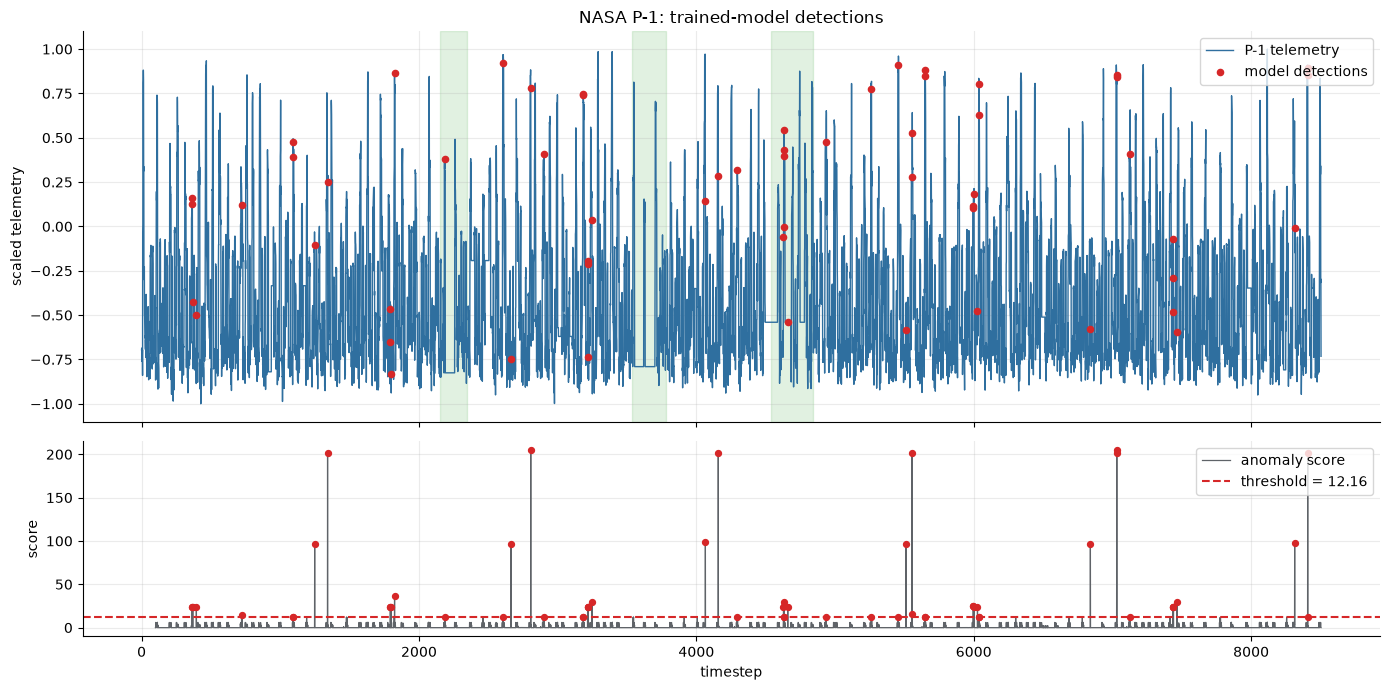

In [4]:
def contiguous_ranges(mask):
    mask = list(bool(x) for x in mask)
    ranges = []
    start = None
    for idx, value in enumerate(mask):
        if value and start is None:
            start = idx
        elif not value and start is not None:
            ranges.append((start, idx - 1))
            start = None
    if start is not None:
        ranges.append((start, len(mask) - 1))
    return ranges

threshold = float(summary["threshold"])

telemetry_path = NASA_DIR / "test" / f"{channel_id}.npy"
telemetry = np.load(telemetry_path)[:, 0] if telemetry_path.exists() else None

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
x = timesteps

if telemetry is not None:
    axes[0].plot(np.arange(len(telemetry)), telemetry, color="#2f6f9f", linewidth=1.0, label=f"{channel_id} telemetry")
    pred_x = timesteps[pred_mask]
    axes[0].scatter(pred_x, telemetry[pred_x], color="#d62728", s=20, label="model detections", zorder=4)
    if label_mask is not None:
        for start, end in contiguous_ranges(label_mask):
            axes[0].axvspan(start, end, color="#2ca02c", alpha=0.14)
    axes[0].set_ylabel("scaled telemetry")
else:
    axes[0].text(0.02, 0.55, f"Raw telemetry file not found: {telemetry_path}", transform=axes[0].transAxes)
    axes[0].set_axis_off()

axes[0].legend(loc="upper right")
axes[0].set_title(f"NASA {channel_id}: trained-model detections")

axes[1].plot(x, score_values, color="#5f6368", linewidth=0.9, label="anomaly score")
axes[1].axhline(threshold, color="#d62728", linestyle="--", linewidth=1.5, label=f"threshold = {threshold:.2f}")
axes[1].scatter(timesteps[pred_mask], score_values[pred_mask], color="#d62728", s=18, zorder=4)
axes[1].set_ylabel("score")
axes[1].set_xlabel("timestep")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [5]:
pred_ranges = contiguous_ranges(pred_mask)
label_ranges = contiguous_ranges(label_mask) if label_mask is not None else []

range_rows = [
    ["Detected ranges, first 12", pred_ranges[:12]],
    ["Label ranges", label_ranges],
    ["Detected range count", len(pred_ranges)],
    ["Label range count", len(label_ranges)],
]
display(html_table(range_rows, headers=["Item", "Value"]))

valid_indices = np.where(np.isfinite(score_values))[0]
top_indices = valid_indices[np.argsort(score_values[valid_indices])[-10:]][::-1]
top_rows = []
for idx in top_indices:
    row = [int(timesteps[idx]), f"{score_values[idx]:.3f}", int(pred_mask[idx])]
    if label_mask is not None:
        row.append(int(label_mask[idx]))
    top_rows.append(row)
headers = ["timestep", "score", "is_anomaly"] + (["label"] if label_mask is not None else [])
display(html_table(top_rows, headers=headers))

Item,Value
"Detected ranges, first 12","[(364, 365), (369, 369), (395, 395), (724, 724), (1093, 1093), (1095, 1095), (1248, 1248), (1341, 1341), (1793, 1794), (1798, 1798), (1824, 1824), (2186, 2186)]"
Label ranges,"[(2149, 2349), (3539, 3779), (4536, 4844)]"
Detected range count,46
Label range count,3


timestep,score,is_anomaly,label
7032,204.645,1,0
2806,204.597,1,0
8408,201.649,1,0
1341,201.338,1,0
4158,201.332,1,0
5555,201.331,1,0
7031,201.047,1,0
4065,98.812,1,0
8314,97.266,1,0
1248,96.970,1,0


## Saved Plots

The project also saves static plot artifacts during inference. These are useful as backup visuals if a live plotting cell is skipped during a presentation.

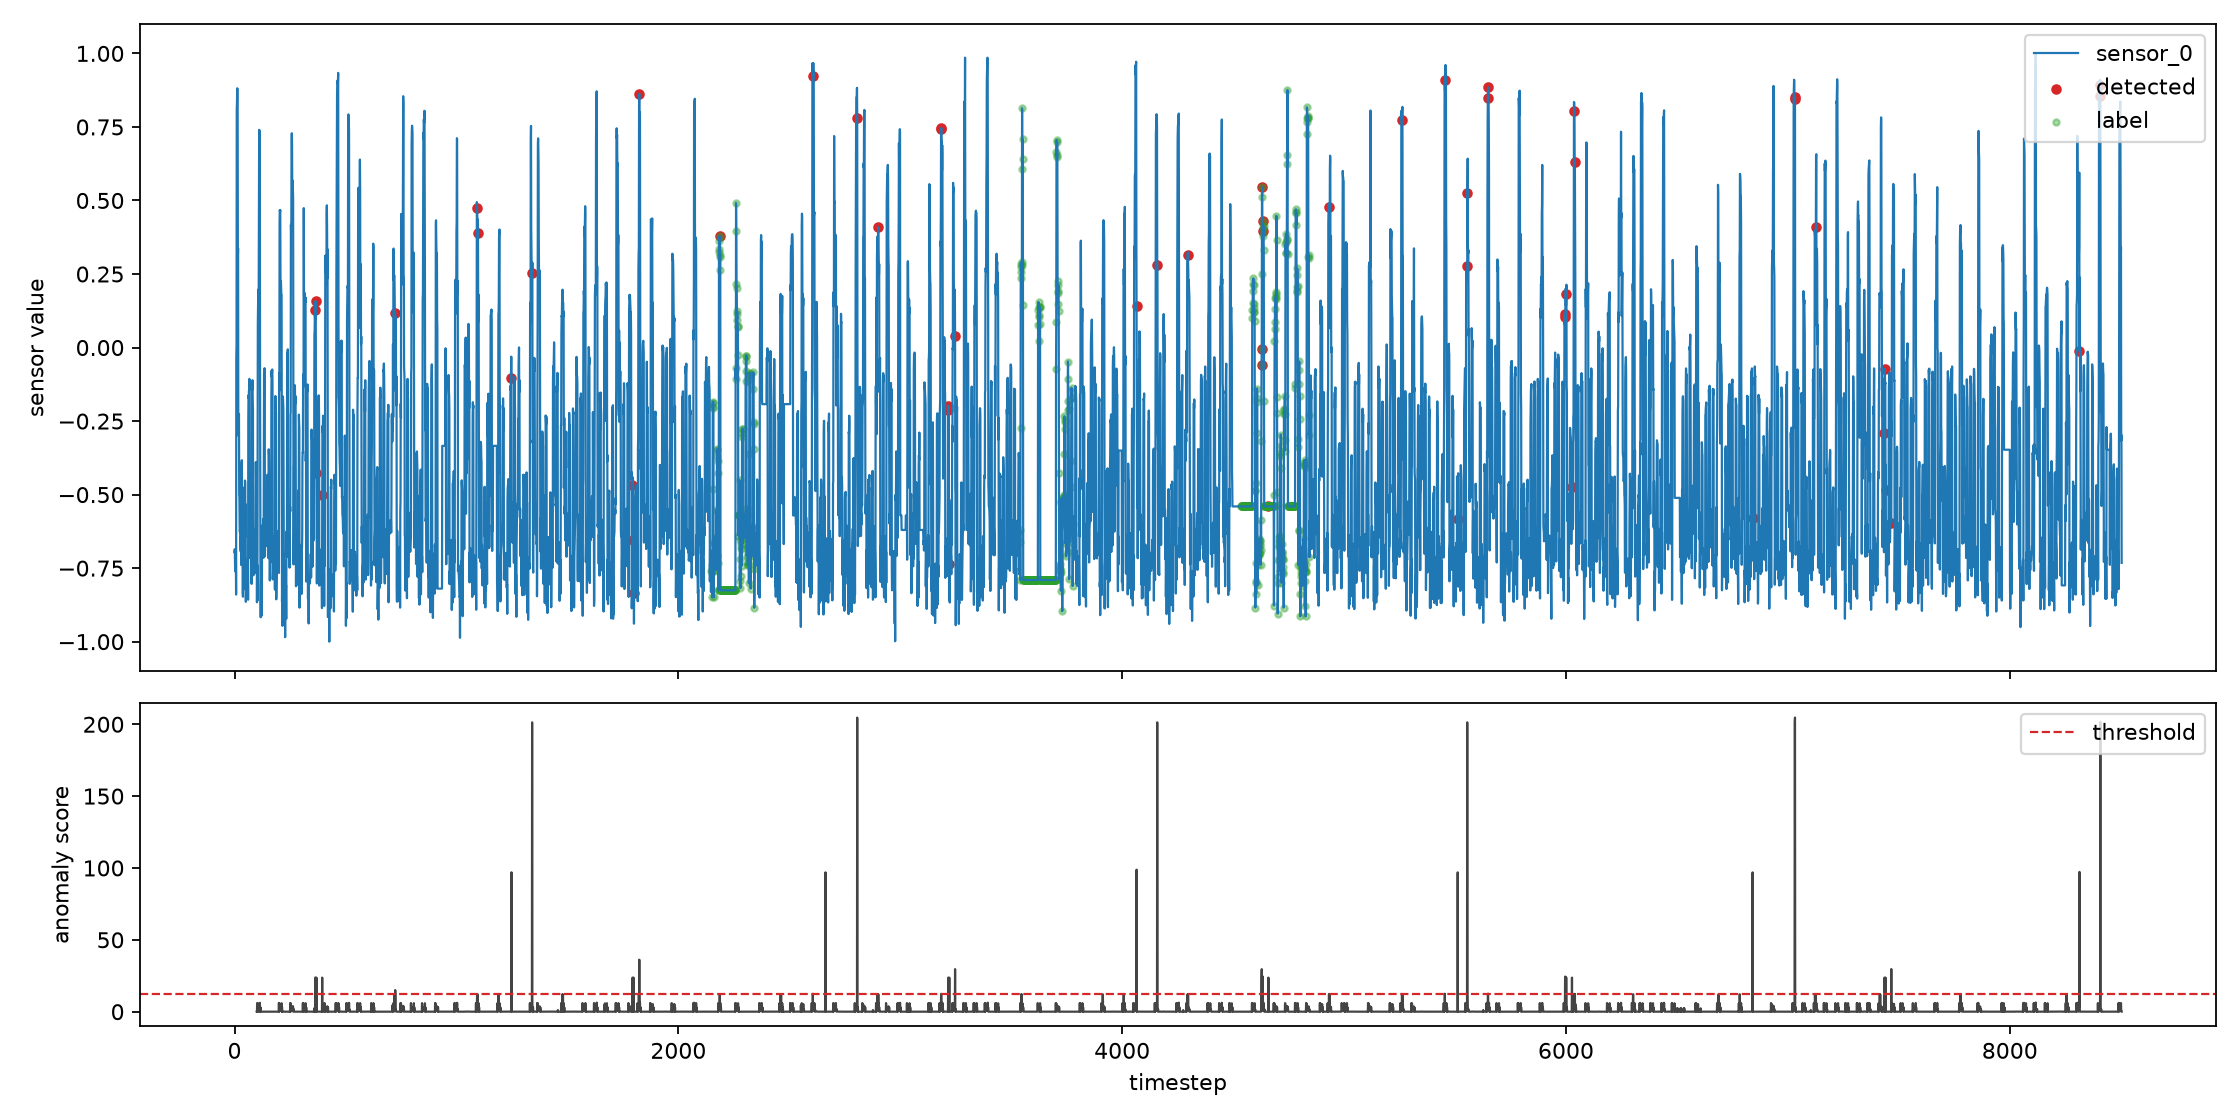

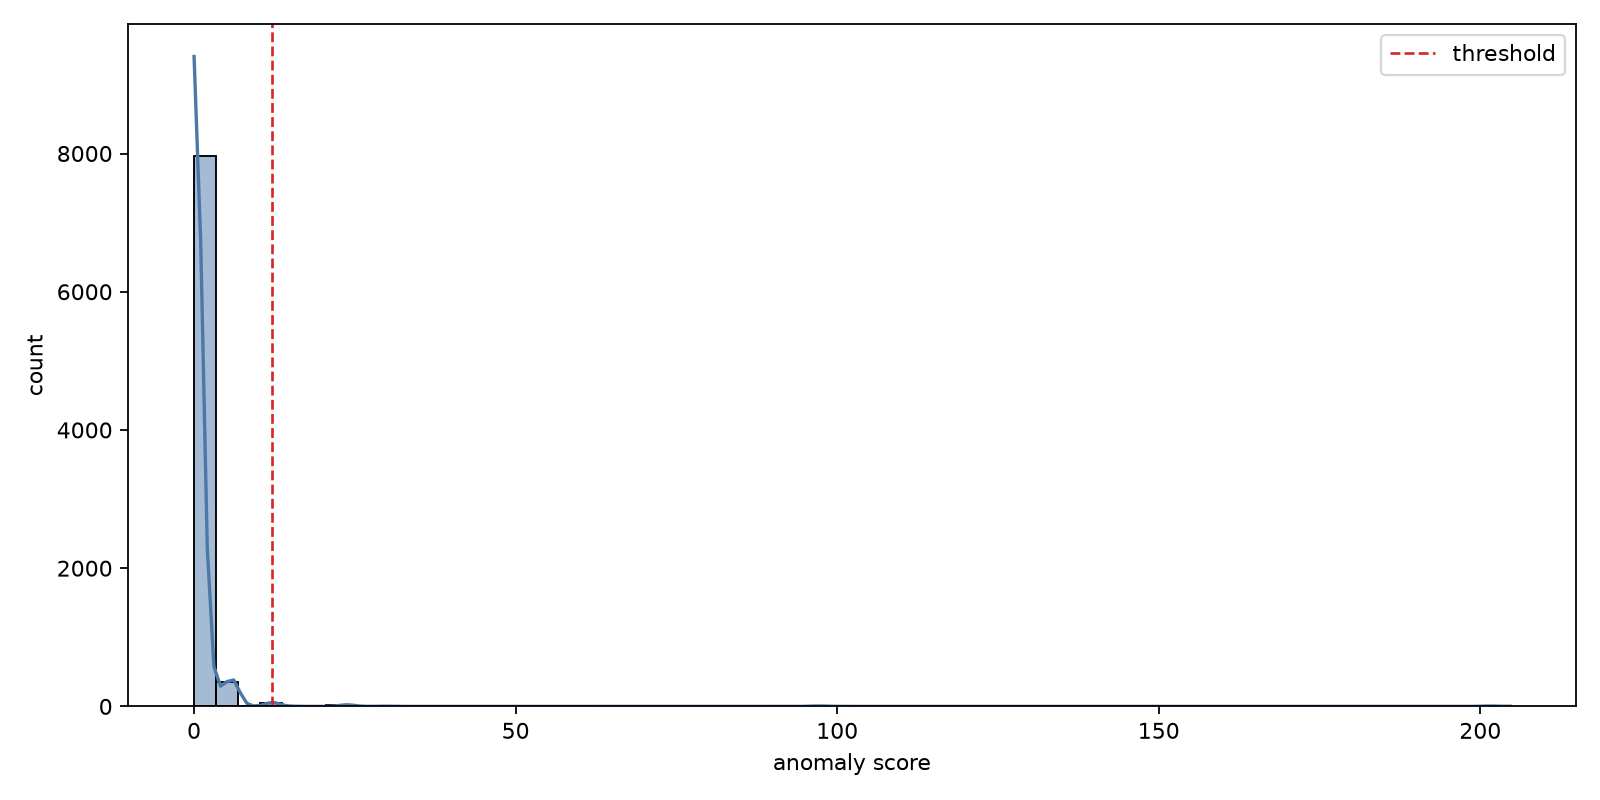

In [6]:
display(Image(filename=str(OUTPUT_DIR / "plots" / "test_scores.png")))
display(Image(filename=str(OUTPUT_DIR / "plots" / "score_distribution.png")))

## From Model Result to Mission Decision

A detection by itself is not enough for deep-space operations. The response layer needs to answer:

- What subsystem might this concern?
- Who needs to know?
- What action is safe to take autonomously?
- What should wait for ground review?

`new_scripts/contracts.py` keeps that interface explicit. Contract A is the detector event. Contract B is the decision packet for display or crew action.

In [7]:
from new_scripts.agent import MissionAgent
from new_scripts.contracts import get_channel_context
from new_scripts.detector import Detector
from new_scripts.streamer import stream

context = get_channel_context("S-1", "SMAP")
context_preview = [
    ["channel", context["channel"]],
    ["spacecraft", context["spacecraft"]],
    ["subsystem", context["subsystem"]],
    ["known anomaly window", context["known_anomaly_ranges"]],
    ["affected roles", ", ".join(context["affected_roles"])],
    ["autonomous trigger", f">= {context['elevated_score']} z-score -> isolate_channel"],
    ["sustained trigger", f">= {context['sustained_after']} timesteps -> ground review"],
]
display(html_table(context_preview, headers=["S-1 context field", "Value"]))
display(Markdown(f"**Protocol note.** {context['protocol']}"))

S-1 context field,Value
channel,S-1
spacecraft,SMAP
subsystem,sensor/attitude telemetry
known anomaly window,"[[5300, 5747]]"
affected roles,"flight_director, adcs_officer, systems_engineer, science_payload_lead, ground_comms"
autonomous trigger,>= 5.0 z-score -> isolate_channel
sustained trigger,>= 50 timesteps -> ground review


**Protocol note.** For S-1, isolate the channel from automated trust if a sharp spike exceeds 5 sigma. If the anomaly persists beyond 50 timesteps, treat it as a possible attitude/state-estimation fault, cross-check redundant sensor channels, and queue ground review. Avoid safe mode unless corroborating channels or command history indicate broader spacecraft instability.

## Live S-1 Response Demo

This cell streams the real `S-1.npy` test file from timestep `5200`, runs the rolling z-score detector, and stops on the first anomaly. The mission agent immediately converts that event into crew-facing instructions.

In [8]:
if not S1_PATH.exists():
    raise FileNotFoundError(
        f"Missing {S1_PATH}. Download the NASA dataset before running the live S-1 demo."
    )

detector = Detector(channel="S-1", spacecraft="SMAP")
agent = MissionAgent()
event = None
decision = None

for tick in stream(channel="S-1", start=5200, speed=0):
    event = detector.detect(tick["t"], tick["value"])
    if event:
        decision = agent.decide(event)
        break

if event is None or decision is None:
    raise RuntimeError("The S-1 stream finished without producing an anomaly event.")

display(Markdown("### Contract A: detector event"))
display(html_table(event.items(), headers=["Field", "Value"]))

display(Markdown("### Contract B: mission decision"))
decision_summary = [
    ["event_id", decision["event_id"]],
    ["severity", decision["severity"]],
    ["confidence", decision["confidence"]],
    ["subsystem", decision["subsystem"]],
    ["recommended_action", decision["recommended_action"]],
    ["policy_decision", decision["policy_decision"]],
    ["command", decision["command"]],
    ["policy_reason", decision["policy_reason"]],
]
display(html_table(decision_summary, headers=["Field", "Value"]))

display(Markdown("### Crew instructions"))
display(html_table(decision["crew_instructions"]))

display(Markdown("### Next checks"))
display(html_table([[check] for check in decision["next_checks"]], headers=["check"]))

### Contract A: detector event

Field,Value
event_id,evt_S1_5538
channel,S-1
spacecraft,SMAP
timestep,5538
flagged_range,"[5538, 5538]"
score,5.043147591017413
method,zscore
channel_prefix,S


### Contract B: mission decision

Field,Value
event_id,evt_S1_5538
severity,medium
confidence,0.78
subsystem,sensor/attitude telemetry
recommended_action,isolate_channel
policy_decision,AUTONOMOUS_ACT
command,isolate_channel
policy_reason,action 'isolate_channel' pre-cleared and confidence 0.78 >= 0.60


### Crew instructions

recipient,priority,instruction
flight_director,medium,"Assign S-1 ownership to adcs_officer, systems_engineer; keep the event active until timesteps 5538..5538 are explained."
adcs_officer,medium,"Cross-check S-1 against S-2, A-*, D-*; if the isolation command executes, keep S-1 out of automated estimator trust until redundant telemetry agrees."
ground_comms,low,"Package the raw S-1 slice, command history, and decision packet for the next ground contact window."
systems_engineer,medium,"Trend power, thermal, and command-state context around timesteps 5538..5538 to separate sensor failure from expected spacecraft mode changes."
science_payload_lead,medium,Flag science products generated during the S-1 interval for pointing-quality review before release.


### Next checks

check
"Compare S-1 with S-2, A-*, D-*."
Inspect command history and spacecraft mode around timesteps 5538..5538.
Track whether the flagged range exceeds 50 timesteps.
"Check against known S-1 anomaly ranges: [[5300, 5747]]."


## Closing Narrative

The trained model provides the first layer: a learned expectation of normal telemetry and a surprise score when reality diverges. The mission-response layer provides the second layer: context, ownership, bounded autonomy, and clear instructions.

That is the core story for the demo: anomaly detection is valuable, but operational understanding is what makes it usable for a spacecraft crew and mission-control team.